In [1]:
from mlpkan import MLPKAN, FullStateNonlinearityMLPKAN
from SS_KAN_KUL.data_class_SI import SystemIdentificationDataset
from SS_KAN_KUL.model_state_space import StateSpaceKANModel
import torch
import matplotlib.pyplot as plt

In [2]:
device = 'cpu'

dataset = SystemIdentificationDataset(
    test_case="Silverbox",
    test_flag="arrow_extra",
    norm_flag="minmax",
    device=device,
    states_available=False,
    init_matrices_flag='Silverbox',
)

state_dim = dataset.A_init.shape[0]
input_dim = dataset.u_dim
output_dim = dataset.y_dim

# Input KAN
state_kan_input_size = state_dim + input_dim
state_kan_hidden_layers = [] # Hidden layers for state KAN
state_kan_output_size = state_dim

# Output KAN
output_kan_input_size = state_dim + input_dim
output_kan_hidden_layers = [] # Hidden layers for output KAN
output_kan_output_size = output_dim 

state_kan = FullStateNonlinearityMLPKAN(
            state_kan_input_size,
            state_kan_hidden_layers,
            state_kan_output_size, # Use general kan_hidden_layers config
            subnetwork_shape = [50, 50]
)
output_kan = FullStateNonlinearityMLPKAN(
            output_kan_input_size,
            output_kan_hidden_layers, # Use specific hidden layer config
            output_kan_output_size,
            subnetwork_shape = [50, 50]
)

output_kan = None
model = StateSpaceKANModel(
    dataset.A_init,
    dataset.B_init,
    dataset.C_init,
    dataset.D_init,
    state_kan,
    output_kan,
    trainable_C=True,
    trainable_D=True,
)
model.to(device)

# load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_99_state_[]_output_[]_batch_128_MLPKAN_subnet[200]_1_ReLU_noOut.pth'
# load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_24_state_[2]_output_[2]_batch_128_MLPKAN.pth'
# load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_49_state_[2]_output_[2]_batch_128_MLPKAN_subnet[30, 30]_1_SilU.pth'
load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_14_state_[]_output_[]_batch_32_MLPKAN_subnet[50, 50]_1_SiLU_noOut_noreg_zscore.pth'
state_dict = torch.load(load_model_path, map_location=device)
model.load_state_dict(state_dict)

Is C trainable? True
Is D trainable? True


<All keys matched successfully>

In [3]:
# Total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

# Non-trainable (frozen) parameters
non_trainable_params = total_params - trainable_params
print(f"Non-trainable parameters: {non_trainable_params:,}")

Total parameters: 16,227
Trainable parameters: 16,227
Non-trainable parameters: 0


In [4]:
model.eval()

# Access data and parameters from dataset object
u_train_norm = dataset.u_train_norm
y_train_norm = dataset.y_train_norm
u_test_norm = dataset.u_test_norm
y_test_norm = dataset.y_test_norm
y_min = dataset.x_min 
y_max = dataset.x_max
norm_flag = dataset.norm_flag

pred_train_eval_norm = None
pred_test_eval_norm = None
y_train_norm_target_eval = None
y_test_norm_target_eval = None
pred_state_train_norm = None
pred_state_test_norm = None

state_dim = getattr(model, 'state_dim', None)

# --- Simulate Training Data ---
with torch.no_grad():
    print(f"    Simulating full train sequence ({len(u_train_norm)} steps)...")
    current_state_train = torch.zeros(1, state_dim, device=device)
    output_pred_list_train = []
    state_train_norm_list = []
    state_train_norm_list.append(current_state_train.clone()) # Store x(0) guess
    for t in range(len(u_train_norm)):
        current_input = u_train_norm[t].unsqueeze(0)
        next_state_train, output_pred_train = model(current_state_train, current_input)
        output_pred_list_train.append(output_pred_train)
        state_train_norm_list.append(next_state_train.clone()) # Store x(t+1)
        current_state_train = next_state_train
    pred_train_norm = torch.cat(output_pred_list_train, dim=0).cpu().numpy()
    pred_state_train_norm = torch.cat(state_train_norm_list[1:]).cpu().numpy()
    final_state_from_train = current_state_train.detach()
    target_train_norm = y_train_norm.cpu().numpy()

    # --- Simulate Testing Data ---

    print(f"    Simulating full test sequence ({len(u_test_norm)} steps)...")
    current_state_test = final_state_from_train
    output_pred_list_test = []
    state_test_norm_list = []
    state_test_norm_list.append(current_state_test.clone()) # Store initial state x(0) for test
    for t in range(len(u_test_norm)):
        current_input = u_test_norm[t].unsqueeze(0)
        next_state_test, output_pred_test = model(current_state_test, current_input)
        output_pred_list_test.append(output_pred_test)
        current_state_test = next_state_test
        state_test_norm_list.append(next_state_test.clone()) # Store x(t+1)
    pred_test_norm = torch.cat(output_pred_list_test, dim=0).cpu().numpy()
    target_test_norm = y_test_norm.cpu().numpy()
    pred_state_test_norm = torch.cat(state_test_norm_list[1:]).cpu().numpy()

    Simulating full train sequence (65062 steps)...
    Simulating full test sequence (40475 steps)...


C:\Users\Maarten\AppData\Local\Temp\ipykernel_15784\1554775076.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u = torch.tensor(u_train_norm, device=device)


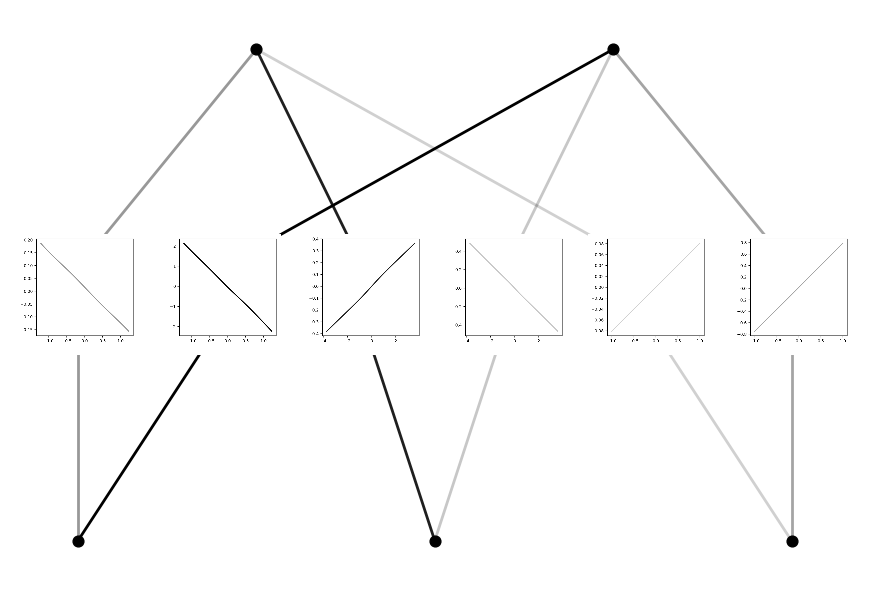

In [5]:

state = torch.tensor(pred_state_train_norm, device=device)
u = torch.tensor(u_train_norm, device=device)
# state = torch.linspace(-1, 1, steps=pred_state_test_norm.shape[0], device=device).unsqueeze(-1).repeat(1, pred_state_test_norm.shape[1])
# u = torch.linspace(-1, 1, steps=u_test_norm.shape[0], device=device).unsqueeze(-1).repeat(1, u_test_norm.shape[1])
if state is not None and u is not None:            
    inp = torch.cat([state, u], dim=-1)
elif state is not None and u is None:             
    inp = state


state_mlpkan_model = model.state_kan_model.kan
state_mlpkan_model(inp, save_activations=True)

state_mlpkan_model.plot(scale=0.5, edge_plot_scale=1.5, attribution_score_alpha=True, tick=True, sample=False)

In [6]:


output_mlpkan_model = model.output_kan_model.kan
test = output_mlpkan_model(inp, save_activations=True)

output_mlpkan_model.plot(scale=0.5, edge_plot_scale=1.5, attribution_score_alpha=False)


AttributeError: 'NoneType' object has no attribute 'kan'

In [ ]:
print(test)

tensor([[ 0.0290],
        [ 0.2706],
        [ 0.3635],
        ...,
        [-0.1480],
        [-0.0577],
        [ 0.0386]], grad_fn=<PermuteBackward0>)
